In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


df = pd.read_csv('../data/cleaned_mushrooms.csv')

# train test split
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 123, stratify = y
)

# One-hot encoding
cat_cols = X.columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [3]:
# Baseline Random Forest

rf_baseline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators = 100, random_state=123))
])
rf_baseline.fit(X_train, y_train)
y_pred_baseline = rf_baseline.predict(X_test)
print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

           e       1.00      1.00      1.00       842
           p       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



Train Scores:  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Test Scores:  [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


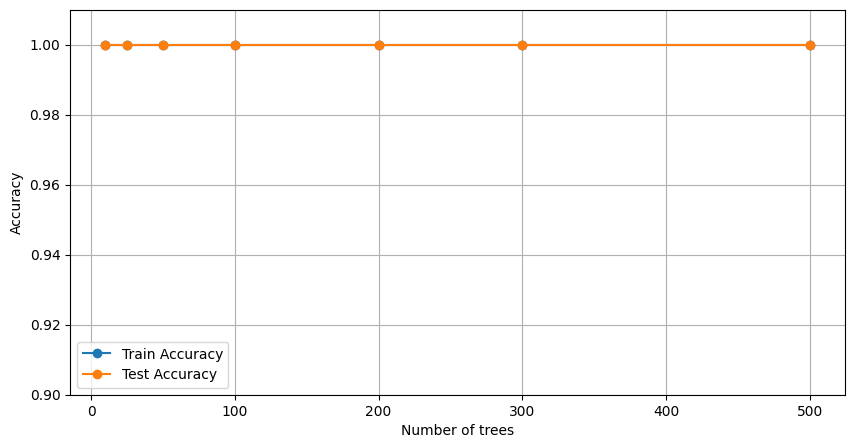

In [10]:
# n estimators 

estimators = [10, 25, 50, 100, 200, 300, 500]
train_scores = []
test_scores = []

for n in estimators:
    rf = Pipeline(steps = [
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators = n, random_state=123))
    ])
    rf.fit(X_train, y_train)
    train_scores.append(rf.score(X_train, y_train))
    test_scores.append(rf.score(X_test, y_test))

print("Train Scores: ", train_scores)
print("Test Scores: ", test_scores)

plt.figure(figsize=(10, 5))
plt.plot(estimators, train_scores, label='Train Accuracy', marker='o')
plt.plot(estimators, test_scores, label='Test Accuracy', marker='o')
plt.xlabel('Number of trees')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.01)
plt.legend()
plt.grid(True)
plt.savefig('../results/rf_estimators.png')
plt.show()

In [11]:
# Grid search for n_estimators

from sklearn.model_selection import GridSearchCV


rf_grid = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=123))
])

param_grid = {
    'classifier__n_estimators': [100,200,300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator = rf_grid,
    param_grid = param_grid,
    cv = 5,
    scoring = 'f1_weighted',
    verbose = 1
)

grid_search.fit(X_train, y_train)
print("Best parameters: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)
print("Test accuracy: ", grid_search.score(X_test, y_test))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters:  {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best score:  1.0
Test accuracy:  1.0


              precision    recall  f1-score   support

           e       1.00      1.00      1.00       842
           p       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



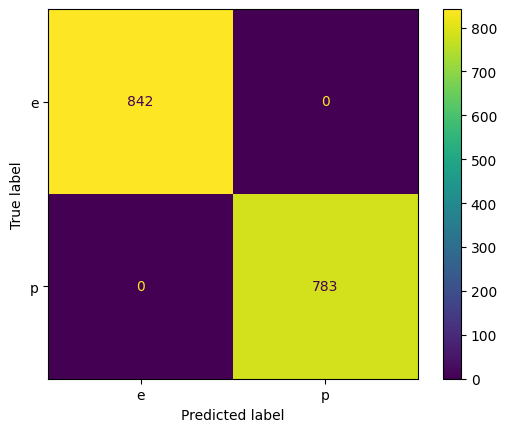

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_best = grid_search.predict(X_test)
print(classification_report(y_test, y_pred_best))
ConfusionMatrixDisplay.from_estimator(grid_search, X_test, y_test)
plt.savefig('../results/rf_confusion_matrix.png')
plt.show()